# **Part 1: Spark Environment Setup**

In [ ]:
# Run this cell and wait for install to complete
# Step 1 installing Java, PySpark and findspark

import os
import subprocess

# Install Java 11
print("📦 Install Java 11...")
os.system("apt-get update -qq && apt-get install -y -qq openjdk-11-jdk-headless > /dev/null 2>&1")

# Setting JAVA_HOME Pathing
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["PATH"] = f"{os.environ['JAVA_HOME']}/bin:" + os.environ["PATH"]

# Install PySpark and findspark (specific versions for compatibility)
print("📦 Install PySpark...")
os.system("pip install -q pyspark==3.5.0 findspark")

# Initialize findspark
import findspark
findspark.init()

print("✅ Setup complete! You can continue.")

📦 Install Java 11...
📦 Install PySpark...
✅ Setup complete! You can continue.


In [ ]:
# Check for Java
java_check = subprocess.run(["java", "-version"], capture_output=True, text=True)
print(f"✅ Java installed: {java_check.stderr.split(chr(10))[0]}")

✅ Java installed: openjdk version "11.0.32" 2026-07-21


In [ ]:
# Step 2: Create a Spark Session

from pyspark.sql import SparkSession
import time

spark = (
    SparkSession.builder
    .appName("MIS769_HW2")
    .master("local[2]")  # Use 2 CPU cores
    .config("spark.driver.memory", "2g")
    .config("spark.ui.showConsoleProgress", "false")  # Cleaner output
    .getOrCreate()
)

print("✅ Spark Session Created!")
print(f"   App Name: {spark.sparkContext.appName}")
print(f"   Master: {spark.sparkContext.master}")
print(f"   Default Parallelism: {spark.sparkContext.defaultParallelism}")

✅ Spark Session Created!
   App Name: MIS769_HW2
   Master: local[2]
   Default Parallelism: 2


Question 1: **What does local[2] mean? What would local[4] do differently?**

Answer here: local[] assigns the number of spark threads to use. [2] is two threads and [4] is four threads, so local[4] is doing more partitions provided the hardware can do it. Local does not check the actual hardware capability unless you use local[*], so using more threads then you have just means the excess threads wait their turn to execute their work.

# **Part 2: Understanding Data Partitioning**

2.1 Create Sample Data and Partition It

In [ ]:
import random

# Create sample data: 100,000 random numbers
data_list = [random.randint(1, 1000) for _ in range(100000)]
print(f"Created {len(data_list):,} data points")

# Create RDD with 4 partitions
rdd = spark.sparkContext.parallelize(data_list, 4)
print(f"Number of partitions: {rdd.getNumPartitions()}")

Created 100,000 data points
Number of partitions: 4


In [ ]:
# Visualize how data is distributed across partitions
def count_partition(index, iterator):
    count = sum(1 for _ in iterator)
    yield (index, count)

partition_counts = rdd.mapPartitionsWithIndex(count_partition).collect()

print("\n📊 DATA DISTRIBUTION ACROSS PARTITIONS")
print("-" * 40)
for partition_id, count in partition_counts:
    bar = "█" * (count // 1000)
    print(f"Partition {partition_id}: {count:,} items {bar}")


📊 DATA DISTRIBUTION ACROSS PARTITIONS
----------------------------------------
Partition 0: 24,576 items ████████████████████████
Partition 1: 25,600 items █████████████████████████
Partition 2: 24,576 items ████████████████████████
Partition 3: 25,248 items █████████████████████████


Experimenting with partitions

In [ ]:
import random

# Create sample data: 100,000 random numbers
data_list = [random.randint(1, 1000) for _ in range(100000)]
print(f"Created {len(data_list):,} data points")

# Create RDD with 8 partitions
rdd = spark.sparkContext.parallelize(data_list, 8)
print(f"Number of partitions: {rdd.getNumPartitions()}")

Created 100,000 data points
Number of partitions: 8


In [ ]:
# Visualize how data is distributed across partitions
def count_partition(index, iterator):
    count = sum(1 for _ in iterator)
    yield (index, count)

partition_counts = rdd.mapPartitionsWithIndex(count_partition).collect()

print("\n📊 DATA DISTRIBUTION ACROSS PARTITIONS")
print("-" * 40)
for partition_id, count in partition_counts:
    bar = "█" * (count // 1000)
    print(f"Partition {partition_id}: {count:,} items {bar}")


📊 DATA DISTRIBUTION ACROSS PARTITIONS
----------------------------------------
Partition 0: 12,288 items ████████████
Partition 1: 12,288 items ████████████
Partition 2: 12,288 items ████████████
Partition 3: 13,312 items █████████████
Partition 4: 12,288 items ████████████
Partition 5: 12,288 items ████████████
Partition 6: 12,288 items ████████████
Partition 7: 12,960 items ████████████


2.2 The MapReduce Pattern

In [ ]:
# MapReduce: Count frequency of each number
# MAP: Transform each number to (number, 1)
# REDUCE: Sum up all the 1s for each number

start_time = time.time()

# The MapReduce pattern
frequency = (
    rdd
    .map(lambda x: (x, 1))           # MAP: (number, 1)
    .reduceByKey(lambda a, b: a + b)  # REDUCE: sum counts
)

# Get top 10 most frequent numbers
top_10 = frequency.takeOrdered(10, key=lambda x: -x[1])

elapsed = time.time() - start_time

print("📊 TOP 10 MOST FREQUENT NUMBERS")
print("-" * 30)
for num, count in top_10:
    print(f"   Number {num:4d}: {count:4d} times")
print(f"\n⏱️ Time taken: {elapsed:.3f} seconds")

📊 TOP 10 MOST FREQUENT NUMBERS
------------------------------
   Number  117:  136 times
   Number  600:  132 times
   Number  680:  131 times
   Number  956:  127 times
   Number  285:  126 times
   Number  428:  125 times
   Number  949:  125 times
   Number  935:  125 times
   Number  368:  124 times
   Number  140:  124 times

⏱️ Time taken: 1.016 seconds


💡 Try It Yourself: Search for Your Favorite Number

How would you search for a specific number? For example, if you want to find how many times the number 103 appears, you could filter the frequency RDD:

# Find count for a specific number
my_number = 103
result = frequency.filter(lambda x: x[0] == my_number).collect()
if result:
    print(f"Number {my_number} appears {result[0][1]} times")
else:
    print(f"Number {my_number} not found")
Try it: Change my_number to your favorite number and run the code above!

In [ ]:
# Try it! Search for your favorite number
my_number = 458  # <-- Change this to any number between 1-1000

result = frequency.filter(lambda x: x[0] == my_number).collect()
if result:
    print(f"🔍 Number {my_number} appears {result[0][1]} times")
else:
    print(f"🔍 Number {my_number} not found in the dataset")

🔍 Number 458 appears 109 times


# **Part 3: Performance Experiment**

Let's measure how the number of cores affects processing speed.

In [ ]:
# Function to run our MapReduce with different core counts
def run_experiment(num_cores, data_size=500000):
    """Run MapReduce with specified number of cores and return timing."""

    # Stop existing session
    spark.stop()

    # Create new session with specified cores
    test_spark = (
        SparkSession.builder
        .appName(f"Test_{num_cores}_cores")
        .master(f"local[{num_cores}]")
        .config("spark.driver.memory", "4g")
        .getOrCreate()
    )

    # Create test data
    test_data = [random.randint(1, 10000) for _ in range(data_size)]
    test_rdd = test_spark.sparkContext.parallelize(test_data, num_cores * 2)

    # Time the MapReduce operation
    start = time.time()

    result = (
        test_rdd
        .map(lambda x: (x, 1))
        .reduceByKey(lambda a, b: a + b)
        .count()  # Force execution
    )

    elapsed = time.time() - start

    test_spark.stop()
    return elapsed

print("Running performance experiment...")
print("(This may take a minute)\n")

Running performance experiment...
(This may take a minute)



In [ ]:
# Run experiments with 1, 2, and 4 cores
import matplotlib.pyplot as plt

results = {}
for cores in [1, 2, 4]:
    print(f"Testing with {cores} core(s)...", end=" ")
    time_taken = run_experiment(cores)
    results[cores] = time_taken
    print(f"{time_taken:.3f} seconds")

# Recreate spark session for later use
spark = (
    SparkSession.builder
    .appName("MIS769_HW2")
    .master("local[2]")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

Testing with 1 core(s)... 1.838 seconds
Testing with 2 core(s)... 1.928 seconds
Testing with 4 core(s)... 3.143 seconds


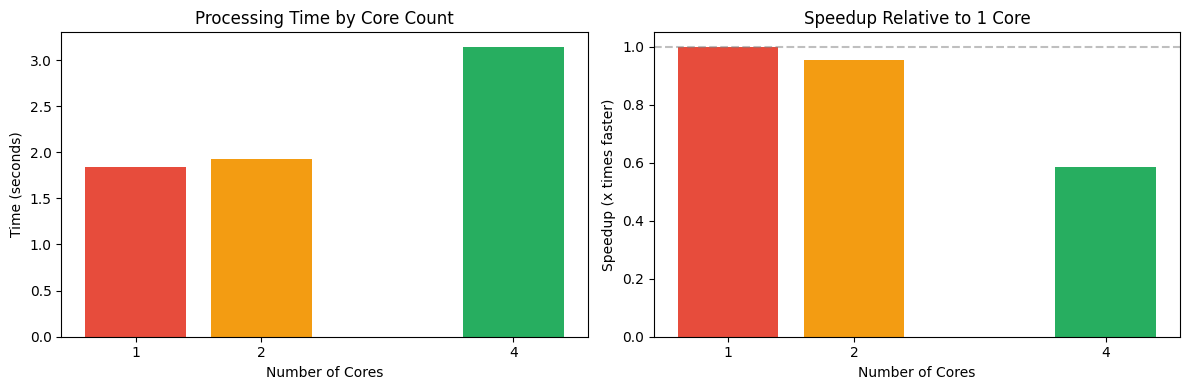


📊 PERFORMANCE SUMMARY
----------------------------------------
1 core(s): 1.838s (speedup: 1.00x)
2 core(s): 1.928s (speedup: 0.95x)
4 core(s): 3.143s (speedup: 0.58x)


In [ ]:
# Visualize the results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cores = list(results.keys())
times = list(results.values())

# Time comparison
axes[0].bar(cores, times, color=['#e74c3c', '#f39c12', '#27ae60'])
axes[0].set_xlabel('Number of Cores')
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title('Processing Time by Core Count')
axes[0].set_xticks(cores)

# Speedup comparison
baseline = results[1]
speedups = [baseline / t for t in times]
axes[1].bar(cores, speedups, color=['#e74c3c', '#f39c12', '#27ae60'])
axes[1].axhline(y=1, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Number of Cores')
axes[1].set_ylabel('Speedup (x times faster)')
axes[1].set_title('Speedup Relative to 1 Core')
axes[1].set_xticks(cores)

plt.tight_layout()
plt.show()

print("\n📊 PERFORMANCE SUMMARY")
print("-" * 40)
for c, t in results.items():
    speedup = baseline / t
    print(f"{c} core(s): {t:.3f}s (speedup: {speedup:.2f}x)")

# **Question 2: Why doesn't 4 cores give exactly 4x speedup? What factors limit the speedup?**

Answer: A 4x performance increase does not occur due to how much of the workload can be done in parallel. Efficency is a fraction that never reaches 1 so the remaining difference til one is the limitation no matter the hardware increase. Factors that can limit performace increase as workload increases would be how much of the work can be parallelized, if the number of requested partitions does not match the number of availble cores. For example 4 partitions but you have 8 cores. Four cores sit idle and are not used efficently. Shuffle and data skew also are barriers. Shuffle is moving data between partitions which increase I/O overhead causing bottlenecks. There can be many other factors as well depending on the culster configuration and type of data being processed.

# **Part 4: Real Data Clustering with Spark ML**

4.1 Create a Streaming Content Dataset

In [ ]:
# Create a realistic streaming content dataset
# (More reliable than external datasets that may be removed)
import pandas as pd
import random

# Generate synthetic streaming data similar to Netflix
random.seed(103)

titles_movies = [
    "The Last Voyage", "City of Dreams", "Dark Waters", "The Forgotten Path",
    "Midnight Sun", "Silent Echo", "The Great Escape", "Beyond Tomorrow",
    "Crimson Peak", "The Final Chapter", "Lost in Time", "Edge of Reality",
    "The Hidden Truth", "Broken Promises", "Endless Night", "Golden Hour",
    "The Perfect Storm", "Shadows Fall", "Rising Phoenix", "Distant Shores"
]

titles_tv = [
    "Crime Files", "The Office Life", "Mystery Manor", "Tech Giants",
    "Family Ties", "Hospital Drama", "Legal Eagles", "Space Frontier",
    "Comedy Hour", "Reality Check", "Cooking Masters", "Nature Wild",
    "Documentary Now", "Teen Dreams", "Action Squad", "Thriller Zone"
]

genres = ["Drama", "Comedy", "Action", "Documentary", "Thriller", "Romance", "Sci-Fi", "Horror"]

# Generate 5000 streaming titles
data = []
for i in range(5000):
    if random.random() < 0.6:  # 60% movies
        title_base = random.choice(titles_movies)
        content_type = "Movie"
        title = f"{title_base} {random.randint(1, 99)}" if random.random() < 0.3 else title_base
    else:  # 40% TV shows
        title_base = random.choice(titles_tv)
        content_type = "TV Show"
        title = f"{title_base}: Season {random.randint(1, 8)}"

    year = random.choices(
        range(1990, 2026),
        weights=[1]*10 + [2]*10 + [4]*10 + [8]*6,  # More recent = more likely
        k=1
    )[0]

    desc_length = random.randint(50, 500)
    description = "A " + " ".join(["word"] * (desc_length // 5))

    data.append({
        "title": title,
        "type": content_type,
        "release_year": year,
        "genre": random.choice(genres),
        "description": description
    })

df_pandas = pd.DataFrame(data)

print(f"✅ Created {len(df_pandas):,} streaming titles")
print(f"   Movies: {len(df_pandas[df_pandas['type']=='Movie']):,}")
print(f"   TV Shows: {len(df_pandas[df_pandas['type']=='TV Show']):,}")
df_pandas.head()

✅ Created 5,000 streaming titles
   Movies: 2,966
   TV Shows: 2,034


,title,type,release_year,genre,description
0,Action Squad: Season 4,TV Show,2021,Comedy,A word word word word word word word word word...
1,Action Squad: Season 6,TV Show,2024,Horror,A word word word word word word word word word...
2,Beyond Tomorrow,Movie,2025,Documentary,A word word word word word word word word word...
3,Family Ties: Season 5,TV Show,2005,Sci-Fi,A word word word word word word word word word...
4,Rising Phoenix,Movie,2020,Romance,A word word word word word word word word word...


In [ ]:
# Convert to Spark DataFrame
df_spark = spark.createDataFrame(df_pandas)

print(f"✅ Converted to Spark DataFrame")
print(f"   Partitions: {df_spark.rdd.getNumPartitions()}")
df_spark.printSchema()

✅ Converted to Spark DataFrame
   Partitions: 2
root
 |-- title: string (nullable = true)
 |-- type: string (nullable = true)
 |-- release_year: long (nullable = true)
 |-- genre: string (nullable = true)
 |-- description: string (nullable = true)



4.2 Prepare Features for Clustering

In [ ]:
from pyspark.sql.functions import col, when, year, length
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans

# Create numeric features for clustering
df_features = df_spark.select(
    col("title"),
    col("type"),
    col("release_year").cast("int").alias("release_year"),
    length(col("description")).alias("description_length")
).dropna()

# Add binary feature for type
df_features = df_features.withColumn(
    "is_movie",
    when(col("type") == "Movie", 1).otherwise(0)
)

print(f"✅ Prepared {df_features.count():,} records for clustering")
df_features.show(5)

✅ Prepared 5,000 records for clustering
+--------------------+-------+------------+------------------+--------+
|               title|   type|release_year|description_length|is_movie|
+--------------------+-------+------------+------------------+--------+
|Action Squad: Sea...|TV Show|        2021|               356|       0|
|Action Squad: Sea...|TV Show|        2024|               111|       0|
|     Beyond Tomorrow|  Movie|        2025|                71|       1|
|Family Ties: Seas...|TV Show|        2005|               256|       0|
|      Rising Phoenix|  Movie|        2020|                91|       1|
+--------------------+-------+------------+------------------+--------+
only showing top 5 rows



In [ ]:
# Assemble features into a vector
feature_cols = ["release_year", "description_length", "is_movie"]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw"
)

# Scale features
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=True
)

# Apply transformations
df_assembled = assembler.transform(df_features)
scaler_model = scaler.fit(df_assembled)
df_scaled = scaler_model.transform(df_assembled)

print("✅ Features assembled and scaled")

✅ Features assembled and scaled


4.3 Run K-Means Clustering

In [ ]:
# Train K-Means model with 3 clusters
kmeans = KMeans(
    k=3,
    seed=103,
    featuresCol="features",
    predictionCol="cluster"
)

model = kmeans.fit(df_scaled)

# Get predictions
predictions = model.transform(df_scaled)

print("✅ K-Means clustering complete!")
print(f"   Number of clusters: {model.getK()}")

✅ K-Means clustering complete!
   Number of clusters: 3


In [ ]:
# Analyze clusters
from pyspark.sql.functions import avg, count

cluster_stats = predictions.groupBy("cluster").agg(
    count("*").alias("count"),
    avg("release_year").alias("avg_year"),
    avg("description_length").alias("avg_desc_length"),
    avg("is_movie").alias("pct_movies")
).orderBy("cluster")

print("\n📊 CLUSTER ANALYSIS")
print("=" * 60)
cluster_stats.show()


📊 CLUSTER ANALYSIS
+-------+-----+------------------+------------------+----------+
|cluster|count|          avg_year|   avg_desc_length|pct_movies|
+-------+-----+------------------+------------------+----------+
|      0| 1529|2014.6788750817527|160.74166121648136|       1.0|
|      1| 2034|2013.9473942969519|276.74237954768927|       0.0|
|      2| 1437|  2014.60751565762| 388.0494084899095|       1.0|
+-------+-----+------------------+------------------+----------+



In [ ]:
# Sample titles from each cluster
print("\n📺 SAMPLE TITLES FROM EACH CLUSTER")
print("=" * 60)

for cluster_id in range(3):
    print(f"\n--- Cluster {cluster_id} ---")
    samples = predictions.filter(col("cluster") == cluster_id).select("title", "type", "release_year").limit(5)
    samples.show(truncate=False)


📺 SAMPLE TITLES FROM EACH CLUSTER

--- Cluster 0 ---
+----------------+-----+------------+
|title           |type |release_year|
+----------------+-----+------------+
|Beyond Tomorrow |Movie|2025        |
|Rising Phoenix  |Movie|2020        |
|Midnight Sun 66 |Movie|2009        |
|The Hidden Truth|Movie|2022        |
|City of Dreams  |Movie|2011        |
+----------------+-----+------------+


--- Cluster 1 ---
+----------------------+-------+------------+
|title                 |type   |release_year|
+----------------------+-------+------------+
|Action Squad: Season 4|TV Show|2021        |
|Action Squad: Season 6|TV Show|2024        |
|Family Ties: Season 5 |TV Show|2005        |
|Legal Eagles: Season 8|TV Show|2018        |
|Tech Giants: Season 2 |TV Show|2011        |
+----------------------+-------+------------+


--- Cluster 2 ---
+----------------+-----+------------+
|title           |type |release_year|
+----------------+-----+------------+
|The Great Escape|Movie|2020        

# **Question 3: Based on your cluster analysis, what characterizes each cluster? Give each cluster a descriptive name (e.g., "Recent TV Shows", "Classic Movies", etc.)**

Answer:

Cluster 0 (Shorter Descriptions): This cluster is about movies and their average description length is substantially shorter than cluster 3.
Cluster 1 (TV Show Cluster): This cluster is only TV Shows
Cluster 2 (Longer Descriptions): This cluster is about movies and what made this cluster unique is the description length is twice as long.

# **Question 4: How does the Map-Reduce pattern apply to your K-Means clustering task? Describe what happens in the Map phase vs the Reduce phase.**

Answer: The Map-Reduce pattern applys by each row's distance from its nearest cluster being mapped to its nearest cluster. This is down across all the partitions. The Reducing occurs by collecting all the like cluster ids of the similar rows. This is also down across all the partitions. The pattern repeats as the mean of the distance per point as assigned by the cluster stops moving for the cluster.

# **Part 5: Draw Your Own Diagram**

The Big Takeaway: Spark takes data and distributes it across cores, across computers, and across clusters. We use Spark when our data is too large to process on a single machine.

# ** Question 5: Create a simple diagram showing how Spark processes your streaming content clustering job.**

Options for creating your diagram:

ASCII art in the code cell below
Draw on paper and take a photo with your phone
Use any drawing tool (PowerPoint, Google Drawings, etc.)
Include in your diagram:

How data is split across partitions (distributed to different workers)
What happens during the Map phase
What happens during the Reduce/Aggregate phase

In [ ]:
print("""
    +-----------------------+
    |     Spark Cluster     |
    +-----------+-----------+
    | Worker 1  | Worker 2  |
    | (Core A)  | (Core B)  |
    +-----+-----+-----+-----+
    | Map | Reduce | Map | Reduce |
    +-----+-----+-----+-----+
           ^     ^
           |     |
           |     Output of Map phase
           +----- Input to Reduce phase
""")

```markdown
## How to insert an image from Google Drive

1.  **Share your image from Google Drive**: Make sure the sharing setting for your image in Google Drive is set to `Anyone with the link` or `Public`.
2.  **Get the shareable link**: Copy the link generated by Google Drive.
3.  **Embed in Markdown**: Use the following Markdown syntax, replacing `YOUR_GOOGLE_DRIVE_FILE_ID` with the actual file ID from your link (it's the part after `id=` in the shareable link).

```
![Alt Text](https://drive.google.com/uc?id=YOUR_GOOGLE_DRIVE_FILE_ID)
```

**Example (replace with your actual image ID):**

```
![Spark Diagram](https://drive.google.com/uc?id=1AbCdEfGhIjKlMnOpQrStUvWxYzA12345)
```
